# Sociolinguistics — does the corpus record enough about its speakers to carry a paper?

The EDA notebook asks what the corpus holds and how recognisers fare on it. This one asks a
different question of the same file, `exports/analytics/analytics.jsonl` (`make export`): **is
there enough social metadata, attached to enough independent speakers, for a sociolinguistic
study of Nepali–English code-mixing?** The answer has two halves. What the corpus *records*
about a speaker is deliberately narrow: declared gender and a twenty-year age bracket, typed by
the annotator from having watched the episode, and a host/guest role (D56, D58). Name, dialect
and origin were refused on purpose, and nothing about a speaker is ever inferred from audio.
What the corpus *lets you derive* is wider: who talks to whom, in what register, how the
English gets in, which address forms are used, and how each of these varies by the recorded
variables.

Eleven questions, in this order:

1. **The inventory.** What a sociolinguistic study asks of a corpus, and which of those the export records, lets you derive, or refuses.
2. **Voices, not clips.** How many independent speakers sit in each demographic cell, and for how long.
3. **Giving each voice its words.** Attributing clip text to a speaker.
4. **Code-mixing across speakers**, by gender, age, role and genre — and the confound between them.
5. **How the English gets in.** Single-word insertion, multi-word alternation, English stems with Nepali morphology, English function words.
6. **Address and honorifics.** The Nepali T/V system (*hajur / tapāī̃ / timī / tã*) by role and genre.
7. **Discourse markers**, Nepali and English, by group.
8. **Accommodation.** Does a host's mixing track the guest's, episode by episode?
9. **Turn-taking by gender pairing.**
10. **What a comparison could detect.** Minimum detectable differences at the current speaker counts.
11. **Verdict**, printed from the frames above.

Every unit of analysis below is a **voice** (an anonymous, cross-episode linked speaker, D87),
never a clip: clips of one person are not independent draws, and a paper's n is its speakers.
The notebook runs no model. Everything comes from the reference transcripts and the metadata.

In [1]:
import json
import re
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ANALYTICS = REPO / "exports" / "analytics" / "analytics.jsonl"
FIGURES = REPO / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Same palette as EDA.ipynb: the first three slots of the reference categorical palette, one
# blue ramp for anything ordered, grey for the unknown.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a"]
SPLITS = ["train", "val", "gold"]
GENRES = ["podcast", "tech_review", "short"]
GENRE_COLOR = dict(zip(GENRES, SLOTS))
GENDERS = ["female", "male"]
GENDER_COLOR = {"female": "#2a78d6", "male": "#eb6834", "unresolved": "#b9b7b0", "mixed": "#1baf7a"}
AGES = ["20_39", "40_59", "60_79"]
ROLES = ["host", "guest"]
ROLE_COLOR = {"host": "#2a78d6", "guest": "#eb6834"}
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
GREY = "#b9b7b0"
INK, MUTED = "#0b0b0b", "#52514e"

plt.style.use("default")
plt.rcParams.update({
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
_installed = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
DEVA_FONT = next((n for n in ("Noto Sans Devanagari", "Noto Serif Devanagari", "FreeSans") if n in _installed), None)


def script_aware(texts):
    """Give labels that contain Devanagari a font list that can draw both scripts."""
    for text in texts:
        if DEVA_FONT and re.search(r"[ऀ-ॿ]", text.get_text()):
            text.set_fontfamily(["DejaVu Sans", DEVA_FONT])
    return texts


def save(fig, name):
    fig.savefig(FIGURES / f"socio_{name}.png", dpi=150, bbox_inches="tight")


def pretty(v):
    return str(v).replace("_", "-")


pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

manifest = json.loads((ANALYTICS.parent / "manifest.json").read_text())
rows, EP_META, talk = [], {}, {}
with ANALYTICS.open(encoding="utf-8") as fh:
    for line in fh:
        r = json.loads(line)
        meta = r["episode_metadata"] or {}
        cls = r["classes"]
        vad = r["vad_spans"] or []
        per_voice = defaultdict(float)
        for t in r["speaker_turns"] or []:
            if t["voice"]:
                per_voice[t["voice"]] += t["end"] - t["start"]
        talk[r["segment_id"]] = dict(per_voice)
        rows.append({
            "segment_id": r["segment_id"], "episode": r["episode_id"],
            "split": "gold" if r["pot"] == "gold" else r["split"],
            "tier": r["verification_tier"], "disposition": r["disposition"],
            "duration": r["duration_seconds"], "speech_s": sum(b - a for a, b in vad),
            "genre": meta.get("genre") or "short", "topic": meta.get("topic") or "unclassified",
            "declared": len(meta.get("speakers") or {}),
            "overlap_s": sum(b - a for a, b in r["overlap_spans"]),
            "turn_changes": max(0, len(r["speaker_turns"] or []) - 1),
            "voice": None if cls["voice"] == "unlinked" else cls["voice"],
            "c_speakers": cls["speakers"], "c_gender": cls["gender"], "c_age": cls["age_bracket"],
            "text": r["text"] or "",
        })
        EP_META.setdefault(r["episode_id"], meta)

seg = pd.DataFrame(rows).set_index("segment_id")
usable = seg[seg.disposition.isin(["accepted_unchanged", "edited"]) & (seg.text.str.len() > 0)].copy()
print(f"{len(seg):,} labeled clips, {seg.duration.sum() / 3600:.2f} h, {seg.episode.nunique()} episodes | exported "
      f"{manifest['exported_at'][:10]} at harness {manifest['git_commit'][:7]}")
print(f"{len(usable):,} clips with an accepted, non-empty reference are the material below")

7,581 labeled clips, 26.69 h, 126 episodes | exported 2026-09-18 at harness 0a60c95
7,556 clips with an accepted, non-empty reference are the material below


## 1. The inventory

What a sociolinguistic study of code-mixing conventionally wants to condition on, against what
the export carries. **Recorded** is typed at ingest; **derived** is computed here from the
transcript, the diarizer's turns or the episode's structure; **refused** was removed on purpose
and will not come back (D56: a name is a join key to a dossier, a dialect label the owner cannot
place reliably is a wrong stratification variable rather than a missing one); **absent** is
simply not collected and could be, since none of it identifies a person. Coverage is computed
in section 2 once voices are resolved, and quoted again in the verdict.

In [2]:
INVENTORY = pd.DataFrame([
    ("speaker gender", "recorded", "episode speakers block: male / female, typed from watching (D58)", "per voice, when the episode's rows force it (sec. 2)"),
    ("speaker age", "recorded", "twenty-year bracket, typed from watching (D58)", "same"),
    ("role in the recording", "recorded", "host / guest per declared speaker", "same"),
    ("interlocutor", "derived", "the other voices in the episode, and their gender/age when resolved", "sec. 9"),
    ("register / genre", "recorded", "podcast, tech review, short reel (ingest form)", "every clip"),
    ("topic", "recorded", "closed taxonomy, LLM-classified from the transcript (D57)", "every clip"),
    ("series / show", "derived", "read off the episode id", "every clip"),
    ("speaking rate, pauses, overlap, hand-overs", "derived", "VAD, overlap detector and diarizer spans (D77, D78)", "every clip"),
    ("code-mixing measures", "derived", "script of every reference token: share, switch points, run lengths, integrated stems", "every clip with text"),
    ("address forms / honorific level", "derived", "second-person pronouns in the reference", "every clip with text"),
    ("discourse markers", "derived", "closed lists, Nepali and English", "every clip with text"),
    ("dialect / region / origin", "refused", "D56: the owner cannot label Nepali dialect reliably; a guessed grouping variable biases everything computed over it", "none"),
    ("name / identity", "refused", "D56", "none"),
    ("education, occupation, class", "absent", "not on the ingest form; could be added as coarse public-profile facts", "none"),
    ("first language, ethnicity, caste", "absent", "not collected; sensitive, and not observable from an episode", "none"),
    ("years abroad / diaspora status", "absent", "not collected", "none"),
    ("recording date, platform, audience size", "absent", "not collected; non-personal and cheap to add at ingest", "none"),
    ("speaker's own language attitudes", "absent", "needs a questionnaire, not a corpus", "none"),
], columns=["variable", "status", "how", "coverage"]).set_index("variable")
display(INVENTORY)

,status,how,coverage
variable,,,
speaker gender,recorded,"episode speakers block: male / female, typed f...","per voice, when the episode's rows force it (s..."
speaker age,recorded,"twenty-year bracket, typed from watching (D58)",same
role in the recording,recorded,host / guest per declared speaker,same
interlocutor,derived,"the other voices in the episode, and their gen...",sec. 9
register / genre,recorded,"podcast, tech review, short reel (ingest form)",every clip
topic,recorded,"closed taxonomy, LLM-classified from the trans...",every clip
series / show,derived,read off the episode id,every clip
"speaking rate, pauses, overlap, hand-overs",derived,"VAD, overlap detector and diarizer spans (D77,...",every clip
code-mixing measures,derived,"script of every reference token: share, switch...",every clip with text


## 2. Voices, not clips

**Method.** pyannote diarizes every episode at its declared speaker count (D79); embeddings are
linked across episodes into anonymous voices (D87). The declared speaker rows carry gender, age
and role but are never linked to a voice by the harness (D78), so a voice inherits a row only
when the assignment is forced, in this order:

1. the episode declares one host and exactly one of its voices recurs in other episodes: that
   voice is the host;
2. every remaining declared row shares a gender and an age: every remaining voice takes them,
   and the role too if the rows share it;
3. one row and one voice are left: they match;
4. as many voices as rows are left and the rows share a gender (or an age): that much is known.

Anything else stays unresolved rather than guessed. This is the EDA notebook's resolver with the
host rule applied first, so that a role can be resolved as well as a gender. A voice's gender,
age and role are then the value its episodes agree on; its genre is where most of its talk time
is, since cross-episode linking can place a voice in a stray episode of another genre.

In [3]:
voice_talk, voice_eps, voice_genre = defaultdict(float), defaultdict(set), defaultdict(Counter)
for sid, per in talk.items():
    if sid in usable.index:
        for v, sec in per.items():
            voice_talk[v] += sec
            voice_eps[v].add(usable.episode[sid])
            voice_genre[v][usable.genre[sid]] += sec
VOICES = sorted(voice_talk)
n_eps = {v: len(voice_eps[v]) for v in VOICES}
FIELDS = ("gender", "age_bracket", "role")

resolved, how = {}, Counter()  # (episode, voice) -> {gender, age_bracket, role?}
for ep_id, meta in EP_META.items():
    rows_ = [dict(r) for r in (meta.get("speakers") or {}).values()]
    present = sorted(v for v in set(usable.voice[usable.episode == ep_id].dropna()))
    if not rows_ or not present:
        continue
    hosts = [r for r in rows_ if r.get("role") == "host"]
    recurring = [v for v in present if n_eps[v] > 1]
    left_rows, left_voices = list(rows_), list(present)
    if len(hosts) == 1 and len(recurring) == 1:
        resolved[(ep_id, recurring[0])] = hosts[0]
        left_rows.remove(hosts[0]); left_voices.remove(recurring[0])
        how["series host"] += 1
    if not left_rows or not left_voices:
        continue
    shared = {k: next(iter(vals)) for k in FIELDS if len(vals := {r.get(k) for r in left_rows}) == 1 and None not in vals}
    if "gender" in shared and "age_bracket" in shared:
        for v in left_voices:
            resolved[(ep_id, v)] = shared
        how["rows agree"] += len(left_voices)
    elif len(left_rows) == 1 and len(left_voices) == 1:
        resolved[(ep_id, left_voices[0])] = left_rows[0]
        how["last row"] += 1
    elif len(left_rows) == len(left_voices) and shared:
        for v in left_voices:
            resolved[(ep_id, v)] = shared
        how["shared rows"] += len(left_voices)


def agree(values):
    vals = {v for v in values if v}
    return vals.pop() if len(vals) == 1 else "unresolved"


def show(ep_id):
    meta = EP_META[ep_id]
    if not meta.get("genre"):
        return "gold reels"
    if meta["genre"] == "tech_review":
        return "tech reviews"
    for prefix, name in (("on_air_with_sanjay_", "On Air with Sanjay"), ("the_bravo_delta_show_", "Bravo Delta Show")):
        if ep_id.startswith(prefix):
            return name
    return "ep_NNN podcast" if re.match(r"ep_\d+_", ep_id) else "other podcasts"


usable["show"] = usable.episode.map(show)
SPK = pd.DataFrame([{
    "voice": v, "episodes": n_eps[v], "talk_min": voice_talk[v] / 60,
    "gender": agree(resolved.get((e, v), {}).get("gender") for e in voice_eps[v]),
    "age": agree(resolved.get((e, v), {}).get("age_bracket") for e in voice_eps[v]),
    "role": agree(resolved.get((e, v), {}).get("role") for e in voice_eps[v]),
    "genre": voice_genre[v].most_common(1)[0][0],  # where most of the voice's talk time is
    "show": ", ".join(sorted({show(e) for e in voice_eps[v]})),
} for v in VOICES]).set_index("voice").sort_values("talk_min", ascending=False)

tot = SPK.talk_min.sum()
print(f"{len(SPK)} voices, {tot / 60:.1f} h of diarized speech; resolution steps: {dict(how)}")
for f in ("gender", "age", "role"):
    known = SPK[f] != "unresolved"
    print(f"  {f:<7} known for {known.sum():>3} voices ({known.mean():.0%}) holding {SPK.talk_min[known].sum() / tot:.0%} of the speech")
cell = SPK[(SPK.gender != "unresolved") & (SPK.age != "unresolved")]
grid = pd.DataFrame({
    "voices": cell.groupby(["gender", "age"]).size(),
    "voices 5+ min": cell[cell.talk_min >= 5].groupby(["gender", "age"]).size(),
    "minutes": cell.groupby(["gender", "age"]).talk_min.sum(),
    "median min / voice": cell.groupby(["gender", "age"]).talk_min.median(),
}).fillna(0).reindex(pd.MultiIndex.from_product([GENDERS, AGES], names=["gender", "age"]), fill_value=0)
display(grid)

125 voices, 25.1 h of diarized speech; resolution steps: {'series host': 38, 'rows agree': 18, 'shared rows': 10}
  gender  known for  30 voices (24%) holding 87% of the speech
  age     known for  24 voices (19%) holding 74% of the speech
  role    known for  22 voices (18%) holding 69% of the speech


voices  voices 5+ min  minutes  median min / voice
gender age                                                      
female 20_39       4              4   302.16               36.86
       40_59       1              1    49.93               49.93
       60_79       1              1    29.52               29.52
male   20_39      10             10   386.98               28.69
       40_59       3              3   158.55               40.35
       60_79       3              3   110.10               26.24

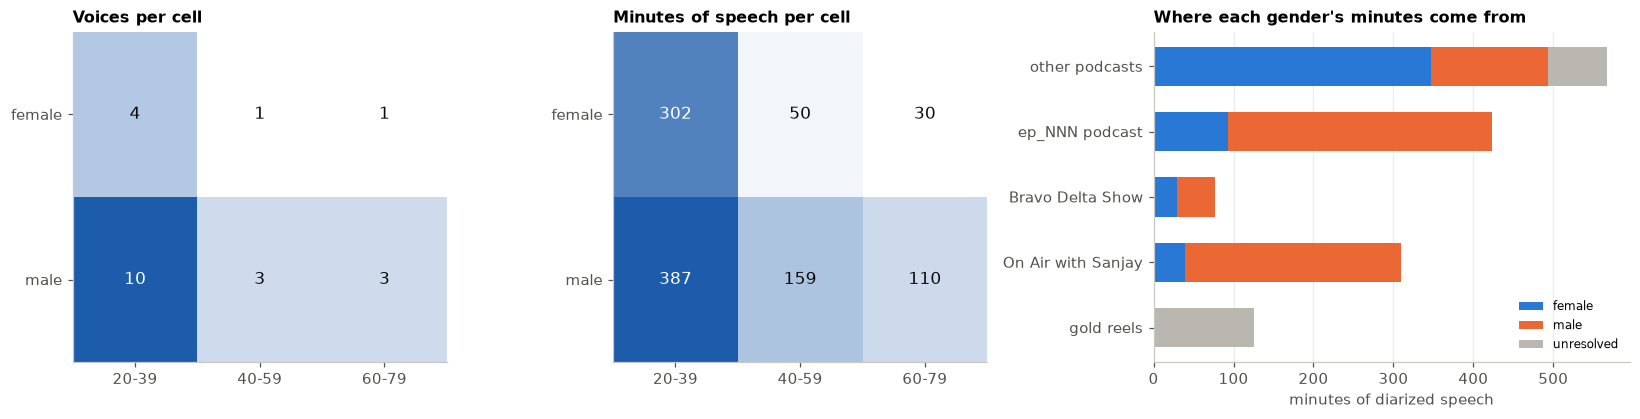

female speech: other podcasts holds 68% of it; gender is confounded with show and genre, so every gender comparison below is also a genre comparison unless it is made within one show.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.9), gridspec_kw={"width_ratios": [1.1, 1.1, 1.4]})
for ax, col, title in ((axes[0], "voices", "Voices per cell"), (axes[1], "minutes", "Minutes of speech per cell")):
    m = grid[col].unstack("age").reindex(GENDERS).reindex(columns=AGES)
    ax.imshow(m.to_numpy(), cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("blue", ["#ffffff", RAMP[3]]), aspect="auto")
    for i, g in enumerate(GENDERS):
        for j, a in enumerate(AGES):
            v = m.loc[g, a]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=11, color="white" if v > m.to_numpy().max() * 0.6 else INK)
    ax.set_xticks(range(len(AGES)), [pretty(a) for a in AGES])
    ax.set_yticks(range(len(GENDERS)), GENDERS)
    ax.set(title=title)
    ax.grid(False)

ax = axes[2]
order = ["gold reels", "tech reviews", "On Air with Sanjay", "Bravo Delta Show", "ep_NNN podcast", "other podcasts"]
by_show = SPK.assign(show1=SPK.show.str.split(", ").str[0]).groupby(["show1", "gender"]).talk_min.sum().unstack(fill_value=0)
by_show = by_show.reindex([s for s in order if s in by_show.index]).reindex(columns=["female", "male", "unresolved"], fill_value=0)
left = np.zeros(len(by_show))
for g in by_show.columns:
    ax.barh(by_show.index, by_show[g], left=left, color=GENDER_COLOR[g], label=g, height=0.6)
    left += by_show[g].to_numpy()
ax.set(title="Where each gender's minutes come from", xlabel="minutes of diarized speech")
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
save(fig, "01_voices_by_cell")
plt.show()
f_share = by_show["female"] / by_show["female"].sum()
print(f"female speech: {f_share.idxmax()} holds {f_share.max():.0%} of it; gender is confounded with show and genre, "
      f"so every gender comparison below is also a genre comparison unless it is made within one show.")

## 3. Giving each voice its words

A clip's reference is one string, but a clip may hold two people. A clip's text is credited to a
voice only when that voice holds at least 90% of the clip's diarized talk; anything more shared
is left out of every per-voice measure. Tokens are the whitespace words of the reference with
edge punctuation removed, classified by script: **Devanagari** (Nepali), **Latin** (English),
**mixed** (a Latin stem carrying Devanagari morphology, *phoneमा*, *photosहरू*), numerals and
other. Fillers are kept, since *uh* versus *अँ* is itself a choice. Sentences are split on the
danda and on `.?!`.

In [5]:
DEV = re.compile(r"[ऀ-ॿ]")
LAT = re.compile(r"[A-Za-z]")
NUM = re.compile(r"^[0-9०-९.,%]+$")
EDGE = ".,;:!?।\"'()[]{}“”‘’-–—…"
SENT_END = re.compile(r"[।.?!]+")

EN_FUNCTION = set("""the a an is are was were be been being am to of and or but in on at for with that this these
those it its i you we they he she my your our their his her me us them not no do does did have has had will would
can could should shall may might if then so because what which who whom how there here as from by about just very
than too also any some all more most much many such there's it's that's i'm you're we're they're don't doesn't didn't
can't won't isn't aren't wasn't""".split())
EN_FILLER = {"uh", "um", "hmm", "mm", "ah", "er"}
HONORIFIC = {"high": ("तपाईं", "तपाई", "तपाईँ", "हजुर"), "mid": ("तिमी", "तिम्र"), "low": ("तँ", "तेर", "तैं", "तैँ")}
DM_NE = {"चाहिँ": "chāhī̃", "चैँ": "chāhī̃", "नि": "ni", "है": "hai", "अनि": "ani", "हैन": "haina", "भनेको": "bhaneko",
         "भन्या": "bhaneko", "मतलब": "matlab", "खै": "khai", "ल": "la"}
DM_EN = {"so", "like", "actually", "basically", "okay", "ok", "right", "yeah", "literally", "obviously", "anyway"}
DM_EN_BIGRAM = {("you", "know"), ("i", "mean")}


def sentences(text):
    out = []
    for sent in SENT_END.split(text):
        toks = []
        for w in sent.split():
            w = w.strip(EDGE)
            if not w:
                continue
            d, l = bool(DEV.search(w)), bool(LAT.search(w))
            toks.append((w, "mixed" if d and l else "dev" if d else "lat" if l else "num" if NUM.match(w) else "other"))
        if toks:
            out.append(toks)
    return out


def features(text):
    f = Counter()
    for sent in sentences(text):
        lex = [(w, c) for w, c in sent if c in ("dev", "lat", "mixed")]
        if not lex:
            continue
        kinds = {c for _, c in lex}
        f["sentences"] += 1
        f["s_nepali" if kinds == {"dev"} else "s_english" if "dev" not in kinds else "s_mixed"] += 1
        prev, run = None, 0
        for w, c in lex:
            f[c] += 1
            side = "en" if c != "dev" else "ne"
            if prev and side != prev:
                f["switches"] += 1
            if side == "en":
                run += 1
            elif run:
                if "dev" in kinds:
                    f[f"run_{min(run, 6)}"] += 1
                    f[f"run_tok_{min(run, 6)}"] += run
                run = 0
            prev = side
            lw = w.lower()
            if c == "lat":
                f["en_function"] += lw in EN_FUNCTION
                f["en_filler"] += lw in EN_FILLER
                f["dm_en"] += lw in DM_EN
                f["en_you"] += lw in ("you", "your", "yours", "you're")
            elif c == "dev":
                f["ne_filler"] += w in ("अँ", "अ", "ऊँ")
                for level, prefixes in HONORIFIC.items():
                    if w.startswith(prefixes):
                        f[f"hon_{level}"] += 1
                        f["hajur_bare"] += w == "हजुर"
                if w in DM_NE:
                    f["dm_ne"] += 1
                    f[f"dmne_{DM_NE[w]}"] += 1
        if run and "dev" in kinds:
            f[f"run_{min(run, 6)}"] += 1
            f[f"run_tok_{min(run, 6)}"] += run
        low = [w.lower() for w, c in lex]
        f["dm_en"] += sum((a, b) in DM_EN_BIGRAM for a, b in zip(low, low[1:]))
    f["tokens"] = f["dev"] + f["lat"] + f["mixed"]
    return dict(f)


feat = pd.DataFrame([features(t) for t in usable.text], index=usable.index).fillna(0).astype(int)
usable = usable.join(feat)
usable = usable[usable.tokens > 0]

dominant = {}
for sid, per in talk.items():
    if per and sid in usable.index:
        v, s = max(per.items(), key=lambda kv: kv[1])
        if s / sum(per.values()) >= 0.9:
            dominant[sid] = v
usable["speaker"] = pd.Series(dominant).reindex(usable.index)
attributed = usable[usable.speaker.notna()].copy()
for f in ("gender", "age", "role"):
    attributed[f] = attributed.speaker.map(SPK[f])

print(f"{len(usable):,} clips, {usable.tokens.sum():,} tokens ({usable.dev.sum() / usable.tokens.sum():.0%} Devanagari, "
      f"{usable.lat.sum() / usable.tokens.sum():.0%} Latin, {usable.mixed.sum() / usable.tokens.sum():.1%} mixed-script)")
print(f"{len(attributed):,} clips ({len(attributed) / len(usable):.0%}) and {attributed.tokens.sum() / usable.tokens.sum():.0%} of tokens "
      f"are credited to one voice; the rest are shared clips and stay out of per-voice measures")
print(f"sentences: {usable.s_nepali.sum() / usable.sentences.sum():.0%} Nepali only, {usable.s_mixed.sum() / usable.sentences.sum():.0%} mixed "
      f"within the sentence, {usable.s_english.sum() / usable.sentences.sum():.0%} English only")

COUNTS = [c for c in feat.columns]
V = attributed.groupby("speaker")[COUNTS].sum()
V = V.join(SPK[["talk_min", "episodes", "gender", "age", "role", "genre", "show"]])
V["english %"] = 100 * (V.lat + V.mixed) / V.tokens
V["switches / 100"] = 100 * V.switches / V.tokens
V["integrated / 1000"] = 1000 * V.mixed / V.tokens
V["en function %"] = 100 * V.en_function / V.lat.clip(lower=1)
V["single-word %"] = 100 * V.run_tok_1 / sum(V[f"run_tok_{k}"] for k in range(1, 7)).clip(lower=1)
V["long-run %"] = 100 * V.run_tok_6 / sum(V[f"run_tok_{k}"] for k in range(1, 7)).clip(lower=1)
V["en sentences %"] = 100 * V.s_english / V.sentences
for level in ("high", "mid", "low"):
    V[f"hon {level} / 1000"] = 1000 * V[f"hon_{level}"] / V.tokens
V["you / 1000"] = 1000 * V.en_you / V.tokens
V["dm ne / 1000"] = 1000 * V.dm_ne / V.tokens
V["dm en / 1000"] = 1000 * V.dm_en / V.tokens
V["en dm share %"] = 100 * V.dm_en / (V.dm_ne + V.dm_en).clip(lower=1)
V["rate w/s"] = attributed.groupby("speaker").tokens.sum() / attributed.groupby("speaker").speech_s.sum().clip(lower=1)
MIN_TOKENS = 300
VV = V[V.tokens >= MIN_TOKENS].copy()
print(f"{len(V)} voices carry attributed text; {len(VV)} have {MIN_TOKENS}+ tokens and are the units of every comparison below "
      f"(gender known for {(VV.gender != 'unresolved').sum()}, age {(VV.age != 'unresolved').sum()}, role {(VV.role != 'unresolved').sum()})")

7,556 clips, 273,093 tokens (68% Devanagari, 31% Latin, 0.6% mixed-script)
5,767 clips (76%) and 71% of tokens are credited to one voice; the rest are shared clips and stay out of per-voice measures
sentences: 29% Nepali only, 60% mixed within the sentence, 11% English only
114 voices carry attributed text; 59 have 300+ tokens and are the units of every comparison below (gender known for 30, age 24, role 22)


## 4. Code-mixing across speakers

Every dot is a voice with 300+ attributed tokens; the bar is the group median. The tests are
Mann–Whitney (two groups) or Kruskal–Wallis (three) on the voice-level values, which is the
right unit but a blunt instrument at these counts: read the n before the p. The tech reviews are
one voice, so they appear as a single point and never as a group; a "genre" comparison is
podcasts against the reels. The last panel is the confound: the same gender split inside the
podcasts alone, where genre is held fixed.

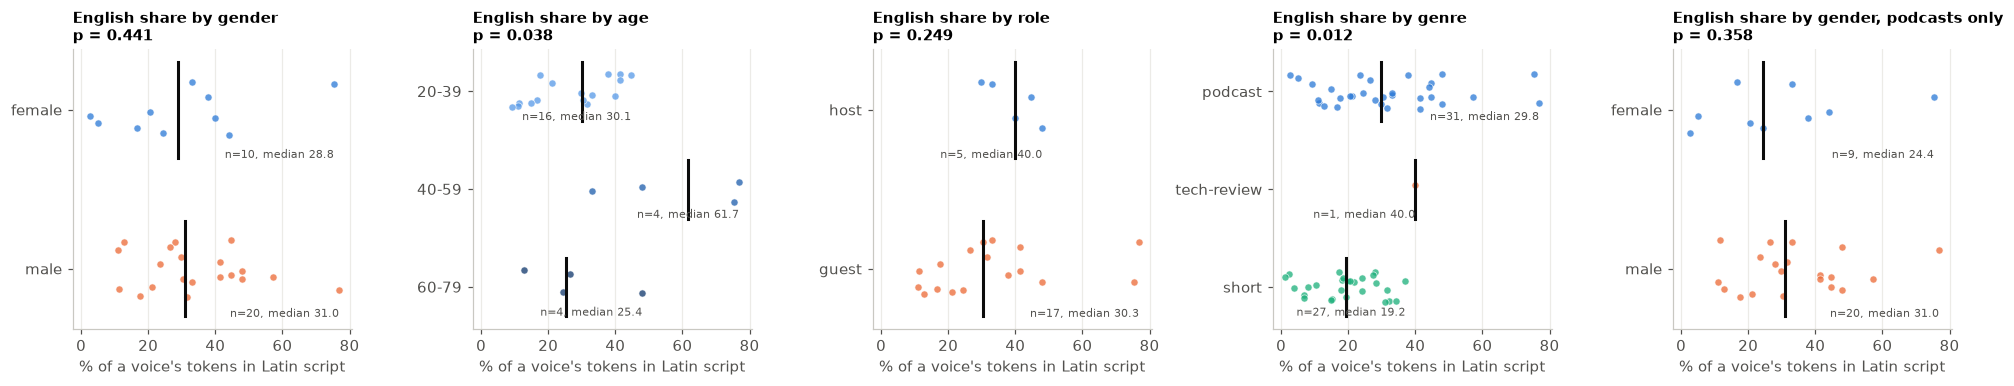

voices  minutes  english %  switches / 100  integrated / 1000  single-word %  long-run %  en function %  rate w/s
comparison               group                                                                                                                     
by gender                female    10.00   510.21      28.77           26.50               6.76          43.39        8.84          17.78      2.54
                         male      20.00   794.62      30.98           20.25               3.99          34.24       22.25          29.70      2.95
                         p           NaN      NaN       0.44            0.98               0.15           0.30        0.16           0.52      0.26
by age                   20_39     16.00   762.44      30.08           28.26               6.35          38.89        6.44          13.92      3.15
                         40_59      4.00   208.48      61.69           13.79               1.35          11.70       59.82          44.85      2.67
                         60_79      4.00   139.61      25.40           11.55               2.27          41.59       17.46          32.04      2.63
                         p           NaN      NaN       0.04            0.01               0.10           0.01        0.00           0.00      0.00
by role                  host       5.00   445.95      39.97           27.71               8.35          29.69       28.05          34.18      2.94
                         guest     17.00   591.27      30.34           24.96               4.87          34.99       10.66          20.12      3.04
                         p           NaN      NaN       0.25            0.45               0.12           0.45        0.39           0.59      0.88
by genre                 podcast   31.00 1,159.07      29.82           20.48               4.57          38.46       10.66          22.24      2.93
                         short     27.00    74.38      19.23           24.36               5.19          49.30        0.00           5.56      3.10
                         p           NaN      NaN       0.01            0.64               0.80           0.19        0.00           0.00      0.23
by gender, podcasts only female     9.00   291.14      24.36           26.49               5.26          44.71        7.37          20.12      2.53
                         male      20.00   794.62      30.98           20.25               3.99          34.24       22.25          29.70      2.95
                         p           NaN      NaN       0.36            0.62               0.27           0.23        0.16           0.59      0.23

In [6]:
def strip(ax, frame, col, by, order, colors, title=None, xlabel=None, min_n=1):
    rng = np.random.default_rng(0)
    groups = [(g, frame.loc[frame[by] == g, col].dropna()) for g in order]
    groups = [(g, s) for g, s in groups if len(s) >= min_n]
    for i, (g, s) in enumerate(groups):
        ax.scatter(s, i + rng.uniform(-0.18, 0.18, len(s)), s=22, color=colors.get(g, GREY), alpha=0.75, edgecolor="white", linewidth=0.5)
        ax.plot([s.median(), s.median()], [i - 0.3, i + 0.3], color=INK, lw=2)
        ax.text(s.max(), i + 0.32, f"n={len(s)}, median {s.median():.1f}", fontsize=7.5, color=MUTED, ha="right", va="bottom")
    ax.set_yticks(range(len(groups)), [pretty(g) for g, _ in groups])
    ax.set(title=title or col, xlabel=xlabel or col)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()
    return groups


def test(frame, col, by, order):
    groups = [frame.loc[frame[by] == g, col].dropna() for g in order if (frame[by] == g).sum() >= 3]
    if len(groups) < 2:
        return np.nan
    return (stats.mannwhitneyu(*groups).pvalue if len(groups) == 2 else stats.kruskal(*groups).pvalue)


pod = VV[VV.genre == "podcast"]
panels = [("gender", GENDERS, GENDER_COLOR, VV, "by gender"), ("age", AGES, dict(zip(AGES, RAMP[1::2] + [RAMP[4]])), VV, "by age"),
          ("role", ROLES, ROLE_COLOR, VV, "by role"), ("genre", GENRES, GENRE_COLOR, VV, "by genre"),
          ("gender", GENDERS, GENDER_COLOR, pod, "by gender, podcasts only")]
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharex=True)
for ax, (by, order, colors, frame, title) in zip(axes, panels):
    strip(ax, frame, "english %", by, order, colors, title=f"English share {title}", xlabel="% of a voice's tokens in Latin script")
    ax.set_title(f"English share {title}\np = {test(frame, 'english %', by, order):.3f}", fontsize=9.5)
fig.tight_layout()
save(fig, "02_mixing_by_group")
plt.show()

METRICS = ["english %", "switches / 100", "integrated / 1000", "single-word %", "long-run %", "en function %", "rate w/s"]
tab = {}
for by, order, _, frame, title in panels:
    for g in order:
        sub = frame[frame[by] == g]
        if len(sub) >= 3:
            tab[(title, g)] = {"voices": len(sub), "minutes": sub.talk_min.sum(), **{m: sub[m].median() for m in METRICS}}
    tab[(title, "p")] = {m: test(frame, m, by, order) for m in METRICS}
tab = pd.DataFrame(tab).T
tab.index.names = ["comparison", "group"]
display(tab.round(2))

## 5. How the English gets in

Three readings that a paper on mixing would want, each of which the transcript supports:

- **Insertion vs alternation** (Muysken's distinction): inside a mixed sentence, how long is a
  stretch of English? A single English word sitting in a Nepali clause is a lexical insertion;
  six or more in a row is a switch into English syntax. The share of English tokens that sit in
  each run length says which of the two this corpus mostly is.
- **Morphological integration**: an English stem taking Nepali plural or case morphology
  (*phonesहरूको*, *Chinaमा*) is the clearest sign of a borrowing that has entered the Nepali
  grammar. The most frequent such tokens are listed, with the Nepali suffixes they take.
- **English function words** as a share of a voice's English: a speaker who inserts nouns has
  almost none; a speaker who switches into English clauses carries *the, is, to, and* with them.

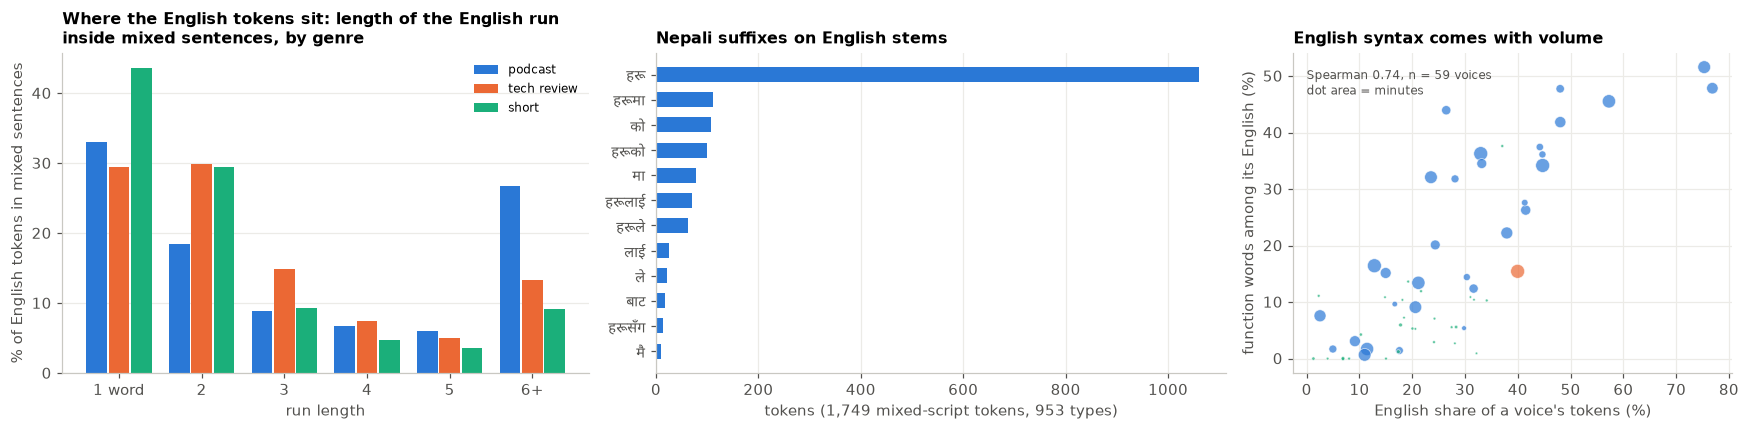

most frequent integrated stems: phoneको (82), phoneमा (55), photosहरू (30), phonesहरू (28), portraitsहरू (17), phonesहरूमा (17), phoneहरूमा (16), colorsहरू (16), phonesहरूको (15), phoneहरू (15), videoहरू (12), gamesहरू (11), issuesहरू (11), phoneले (11), phoneलाई (11)
33% of the English inside mixed sentences is a single word; 23% sits in runs of six or more; 11% of sentences are entirely English


In [7]:
run_cols = [f"run_tok_{k}" for k in range(1, 7)]
RUN_LABELS = ["1 word", "2", "3", "4", "5", "6+"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={"width_ratios": [1.2, 1.3, 1]})
ax = axes[0]
for i, g in enumerate(GENRES):
    sub = usable[usable.genre == g]
    share = 100 * sub[run_cols].sum() / sub[run_cols].sum().sum()
    ax.bar(np.arange(6) + (i - 1) * 0.27, share, 0.25, color=GENRE_COLOR[g], label=g.replace("_", " "))
ax.set_xticks(range(6), RUN_LABELS)
ax.set(title="Where the English tokens sit: length of the English run\ninside mixed sentences, by genre", xlabel="run length", ylabel="% of English tokens in mixed sentences")
ax.grid(axis="x", visible=False)
ax.legend(fontsize=8)

ax = axes[1]
suffix = Counter()
integrated = Counter()
for text in usable.text:
    for w in text.split():
        w = w.strip(EDGE)
        if DEV.search(w) and LAT.search(w):
            integrated[w] += 1
            m = re.match(r"^([A-Za-z'\-]+)([ऀ-ॿ]+)$", w)
            if m:
                suffix[m.group(2)] += 1
top = pd.Series(suffix).sort_values(ascending=False).head(12)
ax.barh(top.index[::-1], top[::-1], color=RAMP[2], height=0.6)
ax.set_yticks(range(len(top)))
script_aware(ax.set_yticklabels(top.index[::-1]))
ax.set(title="Nepali suffixes on English stems", xlabel=f"tokens ({sum(integrated.values()):,} mixed-script tokens, {len(integrated):,} types)")
ax.grid(axis="y", visible=False)

ax = axes[2]
ax.scatter(VV["english %"], VV["en function %"], s=VV.talk_min.clip(2, 60) * 1.4, c=[GENRE_COLOR.get(g, GREY) for g in VV.genre], alpha=0.7, edgecolor="white", linewidth=0.5)
ax.set(title="English syntax comes with volume", xlabel="English share of a voice's tokens (%)", ylabel="function words among its English (%)")
rho = stats.spearmanr(VV["english %"], VV["en function %"])[0]
ax.text(0.03, 0.95, f"Spearman {rho:.2f}, n = {len(VV)} voices\ndot area = minutes", transform=ax.transAxes, va="top", fontsize=8, color=MUTED)
fig.tight_layout()
save(fig, "03_how_english_enters")
plt.show()
print("most frequent integrated stems:", ", ".join(f"{w} ({n})" for w, n in integrated.most_common(15)))
tot_runs = usable[run_cols].sum().sum()
print(f"{100 * usable.run_tok_1.sum() / tot_runs:.0f}% of the English inside mixed sentences is a single word; "
      f"{100 * usable.run_tok_6.sum() / tot_runs:.0f}% sits in runs of six or more; {100 * usable.s_english.sum() / usable.sentences.sum():.0f}% of sentences are entirely English")

## 6. Address and honorifics

Nepali grades its second person: *hajur* and *tapāī̃* are the high forms, *timī* the middle,
*tã* the low one, and the verb agrees with the choice. Which form a host uses to a guest, and
whether guests answer in kind, is a register question the transcript answers directly. *hajur*
on its own also serves as a polite backchannel ("yes?"), which is counted separately. English
*you* is the neutral escape from the choice, and its rate is a fourth column.

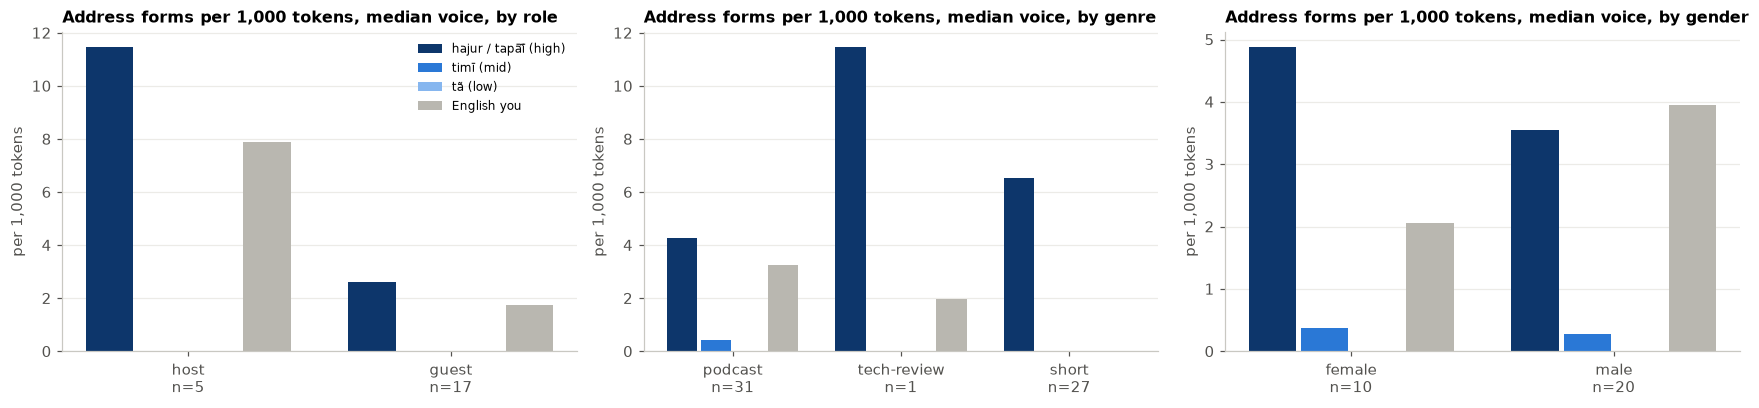

,high / 1000,of which bare hajur,mid / 1000,low / 1000,you / 1000
genre,,,,,
podcast,7.26,2.13,1.96,0.27,6.17
tech_review,11.44,0.29,0.00,0.00,1.95
short,14.56,1.02,0.31,0.00,2.00


the low form tã appears in 9 of 59 voices (On Air with Sanjay, ep_NNN podcast, other podcasts); 21 voices use timī at all


In [8]:
HON_COLS = ["hon high / 1000", "hon mid / 1000", "hon low / 1000", "you / 1000"]
HON_COLORS = [RAMP[4], RAMP[2], RAMP[0], GREY]
HON_LABELS = ["hajur / tapāī̃ (high)", "timī (mid)", "tã (low)", "English you"]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, (by, order) in zip(axes, (("role", ROLES), ("genre", GENRES), ("gender", GENDERS))):
    g = VV[VV[by].isin(order)].groupby(by)[HON_COLS].median().reindex(order)
    n = VV[VV[by].isin(order)].groupby(by).size().reindex(order, fill_value=0).astype(int)
    x = np.arange(len(order))
    for i, (col, color, label) in enumerate(zip(HON_COLS, HON_COLORS, HON_LABELS)):
        ax.bar(x + (i - 1.5) * 0.2, g[col], 0.18, color=color, label=label)
    ax.set_xticks(x, [f"{pretty(o)}\nn={n[o]}" for o in order])
    ax.set(title=f"Address forms per 1,000 tokens, median voice, by {by}", ylabel="per 1,000 tokens")
    ax.grid(axis="x", visible=False)
axes[0].legend(fontsize=8)
fig.tight_layout()
save(fig, "04_address_forms")
plt.show()

hon = usable.groupby("genre")[["hon_high", "hon_mid", "hon_low", "hajur_bare", "en_you", "tokens"]].sum().reindex(GENRES)
hon_t = pd.DataFrame({
    "high / 1000": 1000 * hon.hon_high / hon.tokens, "  of which bare hajur": 1000 * hon.hajur_bare / hon.tokens,
    "mid / 1000": 1000 * hon.hon_mid / hon.tokens, "low / 1000": 1000 * hon.hon_low / hon.tokens, "you / 1000": 1000 * hon.en_you / hon.tokens,
})
display(hon_t)
lo = VV[VV["hon low / 1000"] > 0]
print(f"the low form tã appears in {len(lo)} of {len(VV)} voices ({', '.join(sorted(set(lo.show)))}); "
      f"{(VV['hon mid / 1000'] > 0).sum()} voices use timī at all")

## 7. Discourse markers

Two closed lists. Nepali: *chāhī̃* (topic marker), *ni*, *hai*, *ani*, *haina* (tag), *bhaneko*
("that is"), *matlab*, *khai*, *la*. English: *so, like, actually, basically, okay, right, yeah,
literally, obviously, anyway, you know, I mean*. The English share of a voice's markers is a
sharper index of bilingual discourse than the English share of its words: *so* is the single
most frequent English token in the corpus, ahead of *the*, and a speaker who structures Nepali
talk with *so* and *like* is doing something different from one who names a *phone*.

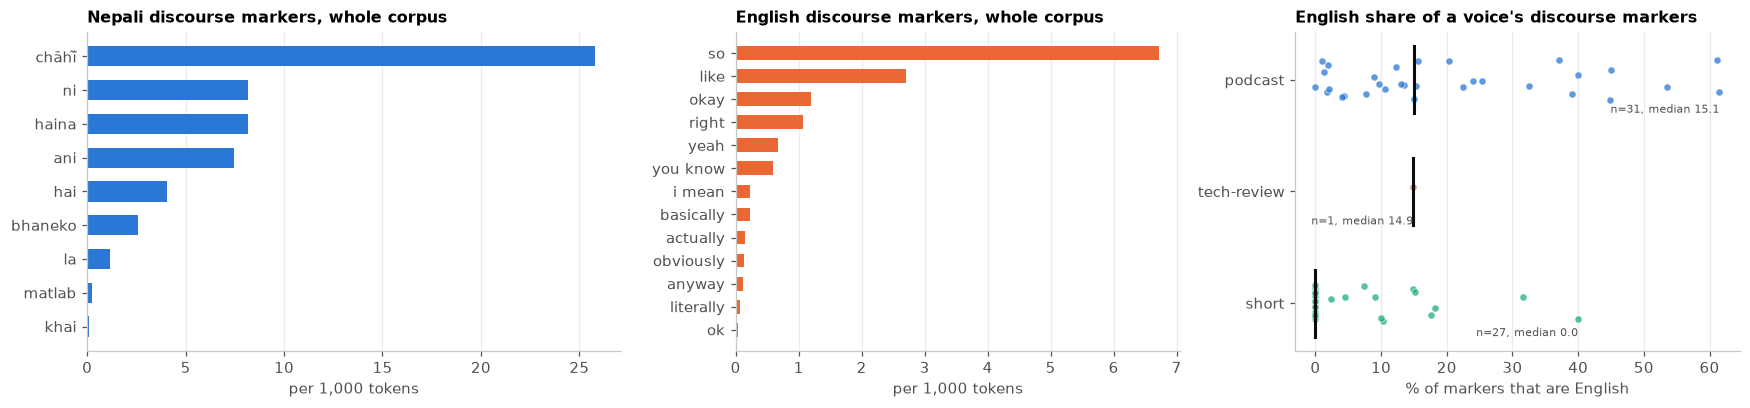

voices  dm ne / 1000  dm en / 1000  en dm share %  p (en dm share)
gender female    10.00         51.61         10.91          17.66             0.88
       male      20.00         71.50         10.33          15.24             0.88
age    20_39     16.00         75.52         11.63          14.21             0.13
       40_59      4.00         20.48         17.66          49.14             0.13
       60_79      4.00         34.31          6.74          18.08             0.13
role   host       5.00         67.33          7.79          14.90             0.82
       guest     17.00         69.60         10.88          15.38             0.82
genre  podcast   31.00         60.65          9.43          15.09             0.00
       short     27.00         50.96          0.00           0.00             0.00

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), gridspec_kw={"width_ratios": [1.2, 1, 1]})
ax = axes[0]
dm_ne = usable[[c for c in usable.columns if c.startswith("dmne_")]].sum().sort_values()
dm_ne.index = [c.replace("dmne_", "") for c in dm_ne.index]
ax.barh(dm_ne.index, 1000 * dm_ne / usable.tokens.sum(), color=RAMP[2], height=0.6)
ax.set(title="Nepali discourse markers, whole corpus", xlabel="per 1,000 tokens")
ax.grid(axis="y", visible=False)

en_dm = Counter()
for text in usable.text:
    low = [w.strip(EDGE).lower() for w in text.split()]
    en_dm.update(w for w in low if w in DM_EN)
    en_dm.update(" ".join(b) for b in zip(low, low[1:]) if b in DM_EN_BIGRAM)
ax = axes[1]
s = pd.Series(en_dm).sort_values()
ax.barh(s.index, 1000 * s / usable.tokens.sum(), color=SLOTS[1], height=0.6)
ax.set(title="English discourse markers, whole corpus", xlabel="per 1,000 tokens")
ax.grid(axis="y", visible=False)

ax = axes[2]
strip(ax, VV, "en dm share %", "genre", GENRES, GENRE_COLOR, title="English share of a voice's discourse markers", xlabel="% of markers that are English")
fig.tight_layout()
save(fig, "05_discourse_markers")
plt.show()
dm_tab = {}
for by, order in (("gender", GENDERS), ("age", AGES), ("role", ROLES), ("genre", GENRES)):
    for g in order:
        sub = VV[VV[by] == g]
        if len(sub) >= 3:
            dm_tab[(by, g)] = {"voices": len(sub), "dm ne / 1000": sub["dm ne / 1000"].median(), "dm en / 1000": sub["dm en / 1000"].median(),
                               "en dm share %": sub["en dm share %"].median(), "p (en dm share)": test(VV, "en dm share %", by, order)}
display(pd.DataFrame(dm_tab).T.round(2))

## 8. Accommodation between host and guest

Speech accommodation predicts that a host's mixing moves toward the guest's. The corpus can test
it two ways. Across episodes: each episode with a resolved host voice and at least one guest
voice gives one (host, guest) pair of English shares. Within a host: the series hosts appear in
many episodes, so for each of them the correlation between their own English share and their
guest's, episode by episode, controls for the host entirely. Both need 100+ attributed tokens
per speaker per episode.

12 episodes with one resolved host and 17 resolved guests


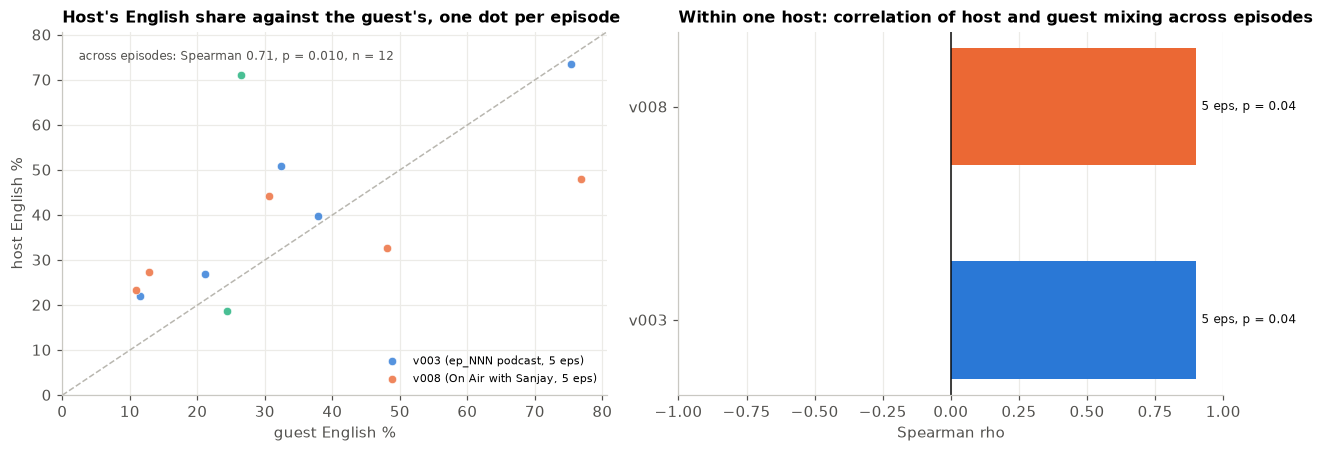

,host,show,episodes,host mean %,host sd %,guest sd %,Spearman,p
0,v003,ep_NNN podcast,5,42.64,20.64,24.42,0.90,0.04
1,v008,On Air with Sanjay,5,35.13,10.68,27.42,0.90,0.04


In [10]:
ep_voice = attributed.groupby(["episode", "speaker"]).agg(tokens=("tokens", "sum"), lat=("lat", "sum"), mixed=("mixed", "sum"))
ep_voice = ep_voice[ep_voice.tokens >= 100]
ep_voice["english %"] = 100 * (ep_voice.lat + ep_voice.mixed) / ep_voice.tokens
ep_voice["role"] = [resolved.get((e, v), {}).get("role") for e, v in ep_voice.index]
pairs = []
for e, sub in ep_voice.groupby(level=0):
    hosts_, guests_ = sub[sub.role == "host"], sub[sub.role == "guest"]
    if len(hosts_) == 1 and len(guests_) >= 1:
        pairs.append({"episode": e, "host": hosts_.index[0][1], "host %": hosts_["english %"].iloc[0],
                      "guest %": np.average(guests_["english %"], weights=guests_.tokens), "guests": len(guests_), "show": show(e)})
pairs = pd.DataFrame(pairs)
print(f"{len(pairs)} episodes with one resolved host and {pairs.guests.sum()} resolved guests")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
host_ids = pairs.host.value_counts()
host_color = {h: SLOTS[i] if i < 3 else GREY for i, h in enumerate(host_ids.index)}
for h, sub in pairs.groupby("host"):
    ax.scatter(sub["guest %"], sub["host %"], s=30, color=host_color[h], alpha=0.8, edgecolor="white", linewidth=0.5,
               label=f"{h} ({sub.show.iloc[0]}, {len(sub)} eps)" if len(sub) >= 3 else None)
lim = [0, max(pairs["guest %"].max(), pairs["host %"].max()) * 1.05]
ax.plot(lim, lim, color=GREY, lw=1, ls="--")
ax.set(title="Host's English share against the guest's, one dot per episode", xlabel="guest English %", ylabel="host English %", xlim=lim, ylim=lim)
ax.legend(fontsize=7.5, loc="lower right")
rho_all = stats.spearmanr(pairs["guest %"], pairs["host %"])
ax.text(0.03, 0.95, f"across episodes: Spearman {rho_all[0]:.2f}, p = {rho_all[1]:.3f}, n = {len(pairs)}", transform=ax.transAxes, va="top", fontsize=8, color=MUTED)

ax = axes[1]
within = []
for h, sub in pairs.groupby("host"):
    if len(sub) >= 5:
        r = stats.spearmanr(sub["guest %"], sub["host %"])
        within.append({"host": h, "show": sub.show.iloc[0], "episodes": len(sub), "host mean %": sub["host %"].mean(), "host sd %": sub["host %"].std(),
                       "guest sd %": sub["guest %"].std(), "Spearman": r[0], "p": r[1]})
within = pd.DataFrame(within).sort_values("episodes", ascending=False)
if len(within):
    ax.barh(within.host, within.Spearman, color=[host_color[h] for h in within.host], height=0.55)
    for y, r in enumerate(within.itertuples()):
        ax.text(r.Spearman + (0.02 if r.Spearman >= 0 else -0.02), y, f"{r.episodes} eps, p = {r.p:.2f}", va="center", ha="left" if r.Spearman >= 0 else "right", fontsize=8, color=INK)
    ax.axvline(0, color=INK, lw=1)
    ax.set(title="Within one host: correlation of host and guest mixing across episodes", xlabel="Spearman rho", xlim=(-1, 1))
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "06_accommodation")
plt.show()
display(within.round(2))

## 9. Turn-taking by gender pairing

Crosstalk and hand-overs are measured on every clip (D77, D78) but carry no speaker, so the
question the corpus can answer is about the *composition* of a conversation, not who interrupts
whom: is a mixed-gender episode more or less overlapped than a same-gender one? Only episodes
whose every voice has a resolved gender count. Composition is a property of the episode, so n is
episodes, and the gold reels (single voice, no declared speakers) fall out.

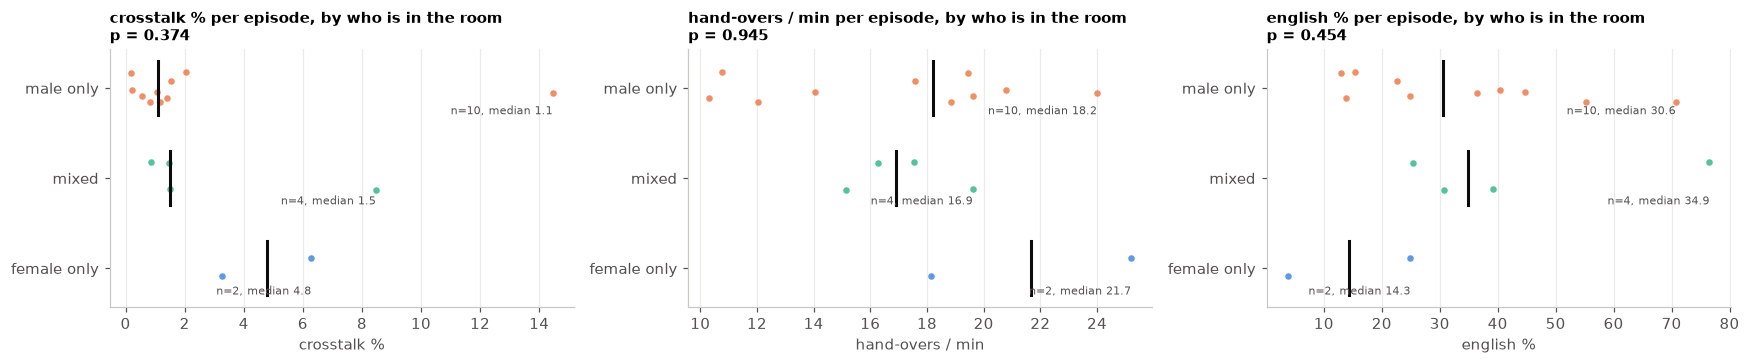

composition,unresolved,one voice,male only,mixed,female only
episodes,83,27,10,4,2


In [11]:
ep_rows = []
for e, sub in usable.groupby("episode"):
    voices = [v for v in set(sub.voice.dropna()) if voice_talk[v] > 0]
    genders = {SPK.gender[v] for v in voices}
    if not voices or "unresolved" in genders or len(voices) < 2:
        comp = "unresolved" if "unresolved" in genders or not voices else "one voice"
    else:
        comp = "mixed" if len(genders) == 2 else f"{genders.pop()} only"
    ep_rows.append({"episode": e, "genre": sub.genre.iloc[0], "show": show(e), "voices": len(voices), "composition": comp,
                    "minutes": sub.duration.sum() / 60, "crosstalk %": 100 * sub.overlap_s.sum() / sub.duration.sum(),
                    "hand-overs / min": 60 * sub.turn_changes.sum() / sub.duration.sum(),
                    "english %": 100 * (sub.lat.sum() + sub.mixed.sum()) / sub.tokens.sum()})
EP = pd.DataFrame(ep_rows).set_index("episode")
COMPS = ["male only", "mixed", "female only"]
COMP_COLOR = {"male only": GENDER_COLOR["male"], "mixed": GENDER_COLOR["mixed"], "female only": GENDER_COLOR["female"]}
conv = EP[EP.composition.isin(COMPS)]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, col in zip(axes, ("crosstalk %", "hand-overs / min", "english %")):
    strip(ax, conv, col, "composition", COMPS, COMP_COLOR, title=f"{col} per episode, by who is in the room", xlabel=col)
    ax.set_title(f"{col} per episode, by who is in the room\np = {test(conv, col, 'composition', COMPS):.3f}", fontsize=9.5)
fig.tight_layout()
save(fig, "07_pairing")
plt.show()
display(EP.composition.value_counts().rename("episodes").to_frame().T)

## 10. What a comparison could detect

The paper's comparisons are between groups of voices. With the voices there are, and the
spread between voices that the corpus shows, the minimum difference in English share (percentage
points) a two-sample test would detect at 80% power and α = 0.05 is given for each split, next
to the difference actually observed. The last column is how many voices *per group* would be
needed to detect the target in the column before it: five points of English share, or one
switch per hundred tokens. This is a t-test power calculation on a quantity that is not normal, so
it is a guide to scale, not a promise.

In [12]:
def mde(n1, n2, sd, alpha=0.05, power=0.8):
    df = n1 + n2 - 2
    return (stats.t.ppf(1 - alpha / 2, df) + stats.t.ppf(power, df)) * sd * np.sqrt(1 / n1 + 1 / n2)


def n_for(delta, sd, alpha=0.05, power=0.8):
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return int(np.ceil(2 * (z * sd / delta) ** 2))


power_rows = []
for metric, target in (("english %", 5.0), ("switches / 100", 1.0)):
    for by, a, b, frame, label in (("gender", "female", "male", VV, "female vs male"), ("gender", "female", "male", pod, "female vs male, podcasts only"),
                                   ("age", "20_39", "40_59", VV, "20-39 vs 40-59"), ("age", "40_59", "60_79", VV, "40-59 vs 60-79"),
                                   ("role", "host", "guest", VV, "host vs guest"), ("genre", "podcast", "tech_review", VV, "podcast vs tech review")):
        x, y = frame.loc[frame[by] == a, metric], frame.loc[frame[by] == b, metric]
        if len(x) < 2 or len(y) < 2:
            continue
        sd = np.sqrt(((len(x) - 1) * x.var() + (len(y) - 1) * y.var()) / (len(x) + len(y) - 2))
        power_rows.append({"metric": metric, "comparison": label, "n": f"{len(x)} vs {len(y)}", "pooled sd": sd, "observed diff": x.mean() - y.mean(),
                           "detectable diff": mde(len(x), len(y), sd), "target": target, "n/group for target": n_for(target, sd)})
POWER = pd.DataFrame(power_rows).set_index(["metric", "comparison"])
display(POWER.round(2))

n  pooled sd  observed diff  detectable diff  target  n/group for target
metric         comparison                                                                                                    
english %      female vs male                 10 vs 20      18.30          -3.99            20.58    5.00                 211
               female vs male, podcasts only   9 vs 20      18.53          -5.10            21.62    5.00                 216
               20-39 vs 40-59                  16 vs 4      14.27         -31.28            23.64    5.00                 128
               40-59 vs 60-79                   4 vs 4      18.38          30.39            43.58    5.00                 213
               host vs guest                   5 vs 17      17.99           6.30            26.95    5.00                 204
switches / 100 female vs male                 10 vs 20       9.91          -0.15            11.14    1.00                1541
               female vs male, podcasts only   9 vs 20       9.64          -1.78            11.25    1.00                1459
               20-39 vs 40-59                  16 vs 4       7.26          14.21            12.03    1.00                 829
               40-59 vs 60-79                   4 vs 4       7.39          -1.23            17.52    1.00                 858
               host vs guest                   5 vs 17      10.07           2.67            15.10    1.00                1593

## 11. Verdict

Printed from the frames above, so a rerun on a newer export rewrites it.

In [13]:
def known(field):
    k = VV[field] != "unresolved"
    return f"{k.sum()} of {len(VV)} voices ({VV.talk_min[k].sum() / VV.talk_min.sum():.0%} of their speech)"


g_n = VV.gender.value_counts()
a_n = VV.age.value_counts()
r_n = VV.role.value_counts()
p_gender = POWER.loc[("english %", "female vs male")]
p_gender_pod = POWER.loc[("english %", "female vs male, podcasts only")] if ("english %", "female vs male, podcasts only") in POWER.index else None
lines = [
    f"UNITS     {len(SPK)} voices in {usable.episode.nunique()} episodes; {len(VV)} voices carry {MIN_TOKENS}+ attributed tokens and are the usable n.",
    f"RECORDED  gender known for {known('gender')}; age {known('age')}; role {known('role')}.",
    f"          cells: " + ", ".join(f"{g}/{pretty(a)} {int(grid.loc[(g, a), 'voices'])}" for g in GENDERS for a in AGES) + " voices (any talk time).",
    f"          female speech is {f_share.max():.0%} {f_share.idxmax()}: gender and genre are confounded outside the podcasts.",
    f"REFUSED   dialect/region and name (D56). ABSENT: education, occupation, L1, ethnicity, diaspora status, recording date.",
    f"DERIVED   English share, switch rate, run lengths, integrated stems, function-word share, address forms, discourse markers, accommodation, pairing: all computed from the reference.",
    f"MIXING    median voice {VV['english %'].median():.0f}% English, {VV['switches / 100'].median():.1f} switches / 100 tokens; "
    f"{100 * usable.run_tok_1.sum() / tot_runs:.0f}% of in-sentence English is a single word (insertion), {100 * usable.run_tok_6.sum() / tot_runs:.0f}% runs of 6+ (alternation).",
    f"          by gender p = {test(VV, 'english %', 'gender', GENDERS):.2f} (n {g_n.get('female', 0)} vs {g_n.get('male', 0)}); "
    f"podcasts only p = {test(pod, 'english %', 'gender', GENDERS):.2f}; by age p = {test(VV, 'english %', 'age', AGES):.2f}; by role p = {test(VV, 'english %', 'role', ROLES):.2f}.",
    f"ADDRESS   high forms {hon_t['high / 1000'].mean():.1f} / 1000 tokens across genres; tã in {len(lo)} voices; timī in {(VV['hon mid / 1000'] > 0).sum()}.",
    f"MARKERS   median voice: {VV['en dm share %'].median():.0f}% of its discourse markers are English; by genre p = {test(VV, 'en dm share %', 'genre', GENRES):.3f}.",
    f"ACCOMMOD. {len(pairs)} host-guest episodes, across-episode Spearman {rho_all[0]:.2f} (p = {rho_all[1]:.2f}); "
    + "; ".join(f"{r.host} within-host rho {r.Spearman:.2f} over {r.episodes} eps" for r in within.itertuples()) + ".",
    f"PAIRING   episodes by composition: " + ", ".join(f"{c} {int((EP.composition == c).sum())}" for c in COMPS) + f"; crosstalk p = {test(conv, 'crosstalk %', 'composition', COMPS):.2f}.",
    f"POWER     gender split detects a {p_gender['detectable diff']:.0f}-point English-share difference (observed {p_gender['observed diff']:+.0f}); "
    f"a 5-point difference needs {int(p_gender['n/group for target'])} voices per group at the observed spread.",
]
if p_gender_pod is not None:
    lines.append(f"          within podcasts: detects {p_gender_pod['detectable diff']:.0f} points with n {p_gender_pod['n']}.")
lines += [
    "SUPPORTS  a descriptive paper on the *form* of Nepali-English mixing (insertion vs alternation, integration, markers, address) with speaker-level variation by role and genre;",
    "          an accommodation study within the recurring hosts; a register contrast between conversational podcasts and the single-voice reels.",
    "          the tech reviews are one speaker, so they illustrate a register but cannot stand for one.",
    "DOES NOT  support a Labovian social-stratification study: no region, class, education or L1; gender is confounded with genre and age cells are thin;",
    "          any gender or age claim needs more female and older voices inside the podcasts, not more hours of the same speakers.",
    "CAVEAT    references are lightly checked fusions of three recognisers (EDA); demographics are the annotator's reading of a public episode, not self-report.",
]
print("\n".join(lines))

UNITS     125 voices in 126 episodes; 59 voices carry 300+ attributed tokens and are the usable n.
RECORDED  gender known for 30 of 59 voices (90% of their speech); age 24 of 59 voices (76% of their speech); role 22 of 59 voices (71% of their speech).
          cells: female/20-39 4, female/40-59 1, female/60-79 1, male/20-39 10, male/40-59 3, male/60-79 3 voices (any talk time).
          female speech is 68% other podcasts: gender and genre are confounded outside the podcasts.
REFUSED   dialect/region and name (D56). ABSENT: education, occupation, L1, ethnicity, diaspora status, recording date.
DERIVED   English share, switch rate, run lengths, integrated stems, function-word share, address forms, discourse markers, accommodation, pairing: all computed from the reference.
MIXING    median voice 24% English, 24.4 switches / 100 tokens; 33% of in-sentence English is a single word (insertion), 23% runs of 6+ (alternation).
          by gender p = 0.44 (n 10 vs 20); podcasts only p = 0.3